In [1]:
# Final Project: Data Dimension Reduction and Denoising using Autoencoders
# Author: Ashish Tiwari (Group 9)

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import time
import math
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [3]:
print("Loading data...")
anime_df = pd.read_csv('anime.csv')
ratings_df = pd.read_csv('rating.csv')

# Filtering to active users only
min_ratings = 50
user_counts = ratings_df['user_id'].value_counts()
valid_users = user_counts[user_counts >= min_ratings].index

# Had to sample 5000 users because using the full dataset kept crashing my local memory
sampled_users = valid_users[:5000] 
ratings_filtered = ratings_df[ratings_df['user_id'].isin(sampled_users)].copy()

user_ids = ratings_filtered['user_id'].unique()
anime_ids = ratings_filtered['anime_id'].unique()

user_to_idx = {x: i for i, x in enumerate(user_ids)}
anime_to_idx = {x: i for i, x in enumerate(anime_ids)}

ratings_filtered['user_idx'] = ratings_filtered['user_id'].map(user_to_idx)
ratings_filtered['anime_idx'] = ratings_filtered['anime_id'].map(anime_to_idx)

num_users = len(user_ids)
num_items = len(anime_ids)

# Calculate matrix sparsity
sparsity = 1.0 - (len(ratings_filtered) / (num_users * num_items))
print(f"Users: {num_users}, Items: {num_items}")
print(f"Matrix Sparsity: {sparsity * 100:.2f}%")

Loading data...
Users: 5000, Items: 11163
Matrix Sparsity: 95.31%


In [5]:
class SparseRatingDataset(Dataset):
    def __init__(self, df, num_items):
        self.num_items = num_items
        self.user_data = {}
        
        grouped = df.groupby('user_idx')
        for user_id, group in grouped:
            self.user_data[user_id] = {
                'indices': group['anime_idx'].values,
                'ratings': group['rating'].values / 10.0 # scale 1-10 to 0-1
            }
        self.user_list = list(self.user_data.keys())

    def __len__(self):
        return len(self.user_list)

    def __getitem__(self, idx):
        user_idx = self.user_list[idx]
        data = self.user_data[user_idx]
        
        vector = torch.zeros(self.num_items)
        vector[data['indices']] = torch.tensor(data['ratings'], dtype=torch.float32)
        return vector

train_data, test_data = train_test_split(ratings_filtered, test_size=0.2, random_state=42)

train_dataset = SparseRatingDataset(train_data, num_items)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

test_dataset = SparseRatingDataset(test_data, num_items)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# print(len(train_dataset)) # testing split sizes
print("Data loaders ready.")

Data loaders ready.


In [7]:
class StackedDenoisingAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super(StackedDenoisingAutoencoder, self).__init__()
        
        # encoder to latent space
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.Tanh(),
            nn.Linear(128, 20), # bottleneck
            nn.Tanh()
        )
        
        # decoder back to original dims
        self.decoder = nn.Sequential(
            nn.Linear(20, 128),
            nn.Tanh(),
            nn.Linear(128, input_dim),
            nn.Sigmoid() 
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

model = StackedDenoisingAutoencoder(num_items).to(device)
criterion = nn.MSELoss()
optimizer = optim.RMSprop(model.parameters(), lr=0.01, weight_decay=1e-5)

In [9]:
epochs = 15
noise_factor = 0.2 
train_losses = []

print("Starting training...")
for epoch in range(epochs):
    start_time = time.time()
    epoch_loss = 0.0
    
    model.train() 
    for batch in train_loader:
        batch = batch.to(device)
        
        # adding gaussian noise for the denoising part
        noisy_batch = batch + noise_factor * torch.randn_like(batch)
        noisy_batch = torch.clamp(noisy_batch, 0., 1.) 
        
        reconstructed = model(noisy_batch)
        
        # masking so we only calculate loss on actual ratings, not the missing zeros
        mask = (batch > 0).float()
        reconstructed_masked = reconstructed * mask
        
        loss = criterion(reconstructed_masked, batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    # print(f"Epoch {epoch+1} done. Loss: {avg_loss:.5f}")
    print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {avg_loss:.5f} | Time: {time.time() - start_time:.2f}s")

Starting training...
Epoch 01/15 | Loss: 0.00254 | Time: 9.31s
Epoch 02/15 | Loss: 0.00094 | Time: 8.98s
Epoch 03/15 | Loss: 0.00137 | Time: 8.16s
Epoch 04/15 | Loss: 0.00111 | Time: 9.01s
Epoch 05/15 | Loss: 0.00093 | Time: 8.33s
Epoch 06/15 | Loss: 0.00094 | Time: 9.00s
Epoch 07/15 | Loss: 0.00150 | Time: 7.84s
Epoch 08/15 | Loss: 0.00094 | Time: 9.37s
Epoch 09/15 | Loss: 0.00093 | Time: 8.16s
Epoch 10/15 | Loss: 0.00096 | Time: 9.18s
Epoch 11/15 | Loss: 0.00093 | Time: 8.53s
Epoch 12/15 | Loss: 0.00093 | Time: 10.82s
Epoch 13/15 | Loss: 0.00094 | Time: 12.21s
Epoch 14/15 | Loss: 0.00099 | Time: 8.21s
Epoch 15/15 | Loss: 0.00095 | Time: 8.82s


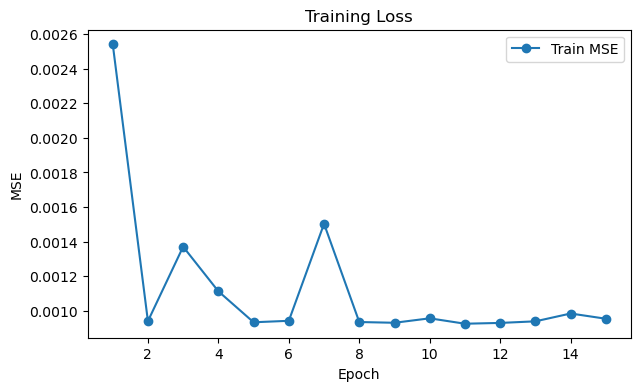

Test RMSE: 2.4467
Test MAE: 2.1804

--- Sample Predictions ---
Hungry Heart: Wild Striker          | Actual: 6.0  | Pred: 5.70
Initial D Fourth Stage              | Actual: 6.0  | Pred: 6.89
Naruto                              | Actual: 6.0  | Pred: 3.40
Prince of Tennis                    | Actual: 5.0  | Pred: 5.30
School Rumble                       | Actual: 1.0  | Pred: 8.67
Neon Genesis Evangelion             | Actual: 1.0  | Pred: 6.06
Rurouni Kenshin: Meiji Kenkaku R... | Actual: 7.0  | Pred: 6.36
Beck                                | Actual: 7.0  | Pred: 6.40
Black Cat                           | Actual: 6.0  | Pred: 6.93
GetBackers                          | Actual: 6.0  | Pred: 7.48


In [11]:
# Plot the training curve
plt.figure(figsize=(7, 4))
plt.plot(range(1, epochs + 1), train_losses, marker='o', label='Train MSE')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()

# Evaluate on test set
model.eval() 
test_mse = 0.0
test_mae = 0.0
total_samples = 0

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        predictions = model(batch) # no noise added during testing
        
        mask = (batch > 0).float()
        preds_masked = predictions * mask
        
        error = (preds_masked * 10) - (batch * 10) # scale back to 1-10 for metrics
        
        num_ratings = torch.sum(mask).item()
        if num_ratings > 0:
            test_mse += torch.sum(error ** 2).item()
            test_mae += torch.sum(torch.abs(error)).item()
            total_samples += num_ratings

final_rmse = math.sqrt(test_mse / total_samples)
final_mae = test_mae / total_samples

print(f"Test RMSE: {final_rmse:.4f}")
print(f"Test MAE: {final_mae:.4f}")
print("\n--- Sample Predictions ---")

# Quick inference check
sample_vector = train_dataset[0].to(device)
with torch.no_grad():
    prediction = model(sample_vector)

actuals = sample_vector.cpu().numpy() * 10
preds = prediction.cpu().numpy() * 10
idx_to_anime = {v: k for k, v in anime_to_idx.items()}

count = 0
for i in range(len(actuals)):
    if actuals[i] > 0: 
        a_id = idx_to_anime[i]
        name = anime_df[anime_df['anime_id'] == a_id]['name'].values[0]
        if len(name) > 35: name = name[:32] + "..."
            
        print(f"{name:<35} | Actual: {actuals[i]:<4.1f} | Pred: {preds[i]:.2f}")
        count += 1
        if count >= 10: break